# CIFAR-10 Image Classification using Convolutional Neural Networks (CNN)

**Name:** _[Your Name Here]_

**Objective:** Build and train a Convolutional Neural Network (CNN) to classify 32×32 color
images into one of 10 categories (airplane, automobile, bird, cat, deer, dog, frog, horse,
ship, truck) using the classic **CIFAR-10** benchmark dataset.

**Dataset:** [CIFAR-10 (Canadian Institute For Advanced Research)](https://www.cs.toronto.edu/~kriz/cifar.html)
(60,000 images total: 50,000 training + 10,000 test, 10 balanced classes)

⚠️ **Note:** This notebook trains a real deep learning model, which is more compute-intensive
than the earlier scikit-learn assignments. Training will run noticeably faster with a GPU
runtime enabled in Colab: **Runtime → Change runtime type → T4 GPU**.

---


## Setup: Loading the Dataset

CIFAR-10 is built directly into Keras, so no manual download, Kaggle account, or API key is
needed — just run the cell below.


In [1]:
# Install the Hugging Face "datasets" library — used here purely to fetch CIFAR-10 quickly.
# NOTE: Keras's built-in cifar10.load_data() downloads from a University of Toronto server,
# which can be extremely slow (20-30+ minutes) depending on your network/region. The Hugging
# Face Hub mirror below uses a fast global CDN and typically downloads in well under a minute.
!pip install datasets -q

import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

# Load CIFAR-10 from the Hugging Face Hub mirror (fast CDN, ~170MB)
hf_dataset = load_dataset("uoft-cs/cifar10")

# Convert from Hugging Face's format (PIL images + integer labels) into plain numpy arrays,
# matching the exact shape/format the rest of this notebook expects.
X_train = np.array([np.array(row) for row in hf_dataset["train"]["img"]])
y_train = np.array(hf_dataset["train"]["label"]).reshape(-1, 1)
X_test = np.array([np.array(row) for row in hf_dataset["test"]["img"]])
y_test = np.array(hf_dataset["test"]["label"]).reshape(-1, 1)

# ---------------------------------------------------------------------------
# ALTERNATIVE (slower, but simpler): Keras's built-in loader. Uncomment if you'd rather use
# this instead — but expect a much longer download time on some networks.
# ---------------------------------------------------------------------------
# from tensorflow.keras.datasets import cifar10
# (X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Dataset loaded successfully!")
print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Test images shape:", X_test.shape)
print("Test labels shape:", y_test.shape)


README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  120MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 23.9MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Dataset loaded successfully!
Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


---
## Task 1: Data Understanding

Let's explore the images and labels before building any model.


In [2]:
# CIFAR-10 has 10 classes, listed in the order the numeric labels (0-9) correspond to
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Class names:", class_names)
print("\nEach image is a", X_train.shape[1], "x", X_train.shape[2], "pixel color image with",
      X_train.shape[3], "channels (Red, Green, Blue)")
print("Pixel value range:", X_train.min(), "to", X_train.max())


Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Each image is a 32 x 32 pixel color image with 3 channels (Red, Green, Blue)
Pixel value range: 0 to 255


/tmp/ipykernel_1559/1141904314.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


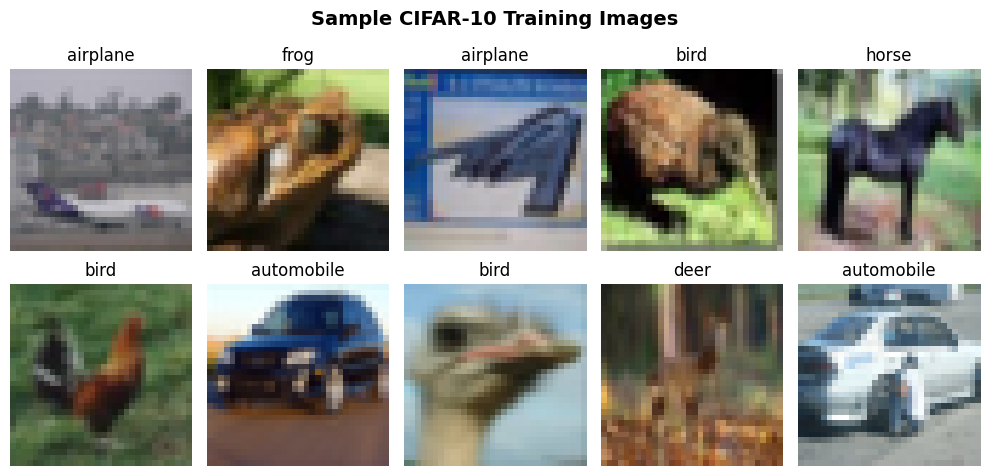

In [3]:
# Let's visualize a handful of sample training images with their labels
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis('off')
plt.suptitle('Sample CIFAR-10 Training Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()


In [4]:
# Check that all 10 classes are evenly balanced (a well-known property of CIFAR-10)
import pandas as pd

unique, counts = np.unique(y_train, return_counts=True)
class_distribution = pd.DataFrame({
    'Class': [class_names[i] for i in unique],
    'Training Count': counts
})
class_distribution


,Class,Training Count
0,airplane,5000
1,automobile,5000
2,bird,5000
3,cat,5000
4,deer,5000
5,dog,5000
6,frog,5000
7,horse,5000
8,ship,5000
9,truck,5000


**Observation:** CIFAR-10 is a **perfectly balanced** dataset — exactly 5,000 training
images and 1,000 test images per class, so we don't need to worry about class imbalance here
(unlike several of our earlier tabular-data assignments).


---
## Task 2: Data Preprocessing

We will:
- Normalize pixel values to the 0-1 range
- Check the label shapes (and reshape if needed)
- Optionally apply data augmentation to help the model generalize better


In [5]:
# Normalize pixel values from the 0-255 range to 0-1.
# Neural networks train much more effectively when inputs are on a small, consistent scale.
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

print("Pixel value range after normalization:", X_train_norm.min(), "to", X_train_norm.max())


Pixel value range after normalization: 0.0 to 1.0


In [6]:
# The labels come as a column vector of shape (N, 1) rather than a flat array of shape (N,).
# We flatten them since that's what our loss function ("sparse_categorical_crossentropy")
# expects — plain integer class labels, not one-hot encoded vectors.
y_train_flat = y_train.flatten()
y_test_flat = y_test.flatten()

print("Label shape before flattening:", y_train.shape)
print("Label shape after flattening:", y_train_flat.shape)


Label shape before flattening: (50000, 1)
Label shape after flattening: (50000,)


### Data Augmentation

To help our CNN generalize better and reduce overfitting, we apply simple **data
augmentation** — randomly flipping, shifting, or rotating training images slightly on each
epoch, so the model sees a slightly different version of the training set every time and
can't simply memorize exact pixel patterns.


In [7]:
# Create a data augmentation pipeline using Keras preprocessing layers.
# These only apply during TRAINING — the test set is never augmented, since we want to
# evaluate the model on the real, unmodified images.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
])

print("Data augmentation pipeline created.")


Data augmentation pipeline created.


---
## Task 3: Model Development — Building the CNN

We build a CNN with three convolutional blocks (each with Conv2D + BatchNormalization +
MaxPooling + Dropout), followed by fully connected layers. Batch normalization stabilizes and
speeds up training; dropout helps prevent overfitting.


In [8]:
# Build the CNN architecture
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,   # augmentation is part of the model, only active during training

    # --- Convolutional Block 1 ---
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # --- Convolutional Block 2 ---
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # --- Convolutional Block 3 ---
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # --- Fully Connected (Dense) Layers ---
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')   # 10 output classes, softmax gives class probabilities
])

# Compile the model: Adam optimizer, sparse categorical crossentropy since our labels are
# plain integers (0-9) rather than one-hot encoded vectors.
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 403,882 (1.54 MB)

 Trainable params: 403,434 (1.54 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
# Use EarlyStopping to automatically stop training if validation loss stops improving,
# which helps prevent overfitting and saves training time.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train the model. This is the most time-consuming step in the notebook.
# 25 epochs is a reasonable starting point — with EarlyStopping, it may finish sooner.
history = model.fit(
    X_train_norm, y_train_flat,
    epochs=25,
    batch_size=64,
    validation_data=(X_test_norm, y_test_flat),
    callbacks=[early_stopping],
    verbose=1
)

print("Model training complete!")


Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.3037 - loss: 1.8884 - val_accuracy: 0.3572 - val_loss: 1.7719
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.4234 - loss: 1.5679 - val_accuracy: 0.4265 - val_loss: 1.7359
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.4902 - loss: 1.4107 - val_accuracy: 0.5284 - val_loss: 1.3640
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.5417 - loss: 1.2960 - val_accuracy: 0.5763 - val_loss: 1.2569
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.5812 - loss: 1.1954 - val_accuracy: 0.5532 - val_loss: 1.4345
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.6126 - loss: 1.1227 - val_accuracy: 0.6557 - val_loss: 1.0242
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.6356 - loss: 1.0604 - val_accuracy: 0.6907 - val_loss: 0.8993
Epoch 8/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.6561 - loss: 1.0051 - 

---
## Task 4: Model Evaluation

We evaluate the trained model using accuracy on the test set, a classification report
(precision/recall/F1 per class), and a confusion matrix. We also plot training curves to check
for overfitting.


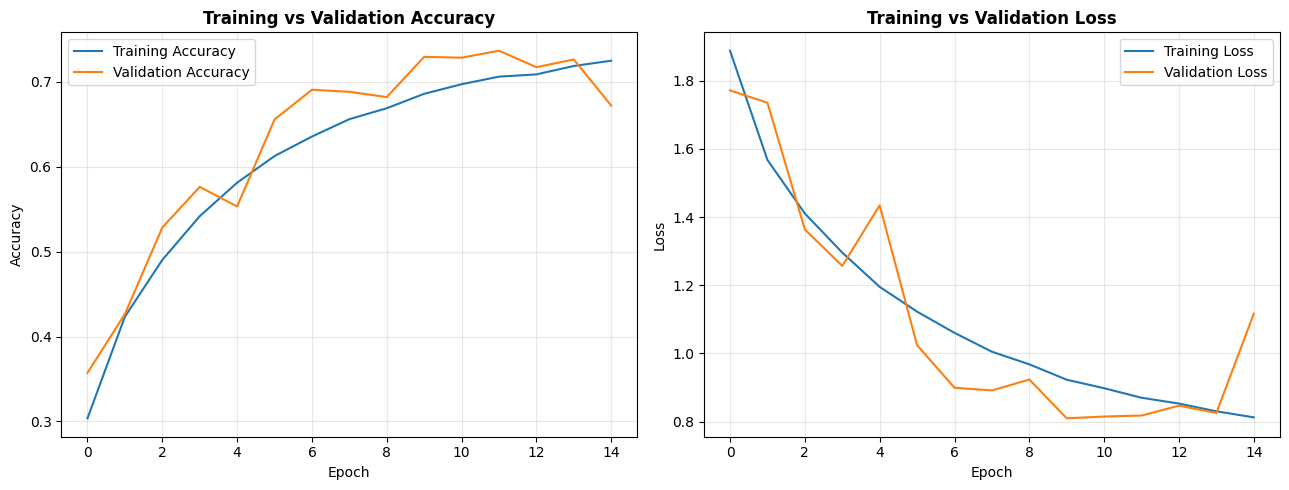

In [10]:
# Plot training & validation accuracy and loss curves over epochs
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training vs Validation Accuracy', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training vs Validation Loss', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()


In [11]:
# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_test_norm, y_test_flat, verbose=0)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 0.7295
Test Loss: 0.8096


In [12]:
# Generate predictions and a detailed classification report (precision/recall/F1 per class)
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred_probs = model.predict(X_test_norm)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test_flat, y_pred_classes, target_names=class_names))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

    airplane       0.64      0.86      0.74      1000
  automobile       0.74      0.96      0.84      1000
        bird       0.72      0.48      0.58      1000
         cat       0.56      0.55      0.56      1000
        deer       0.75      0.62      0.68      1000
         dog       0.78      0.53      0.63      1000
        frog       0.74      0.85      0.79      1000
       horse       0.75      0.81      0.77      1000
        ship       0.90      0.81      0.85      1000
       truck       0.76      0.82      0.79      1000

    accuracy                           0.73     10000
   macro avg       0.73      0.73      0.72     10000
weighted avg       0.73      0.73      0.72     10000



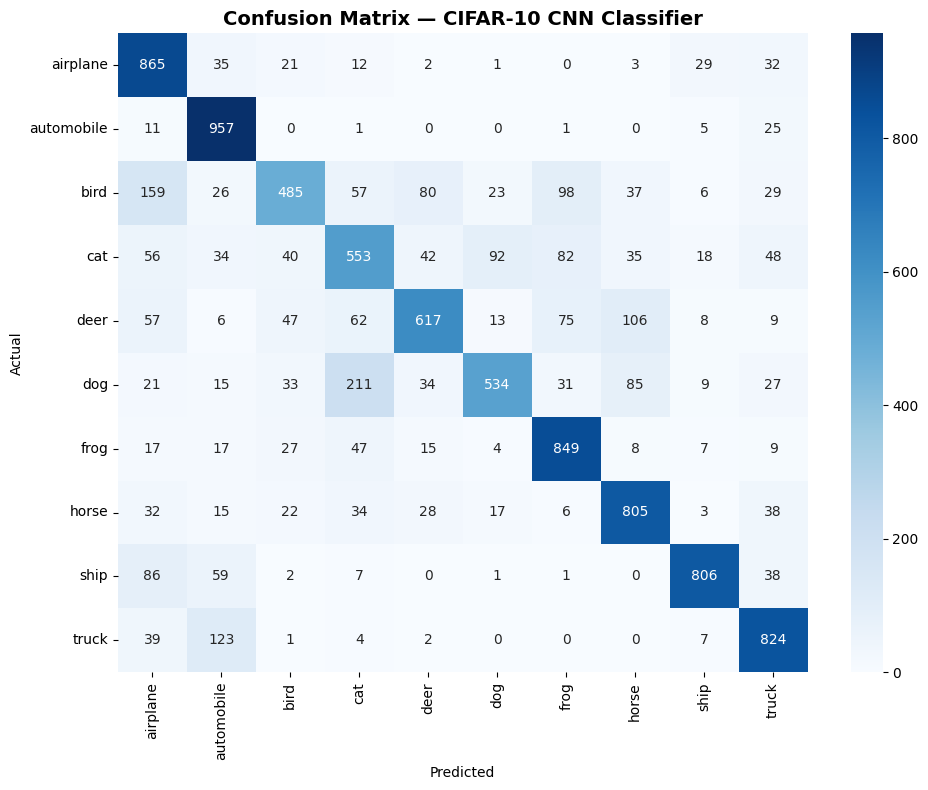

In [13]:
# Confusion matrix: shows exactly which classes get confused with each other
cm = confusion_matrix(y_test_flat, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — CIFAR-10 CNN Classifier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_cifar.png', dpi=150)
plt.show()


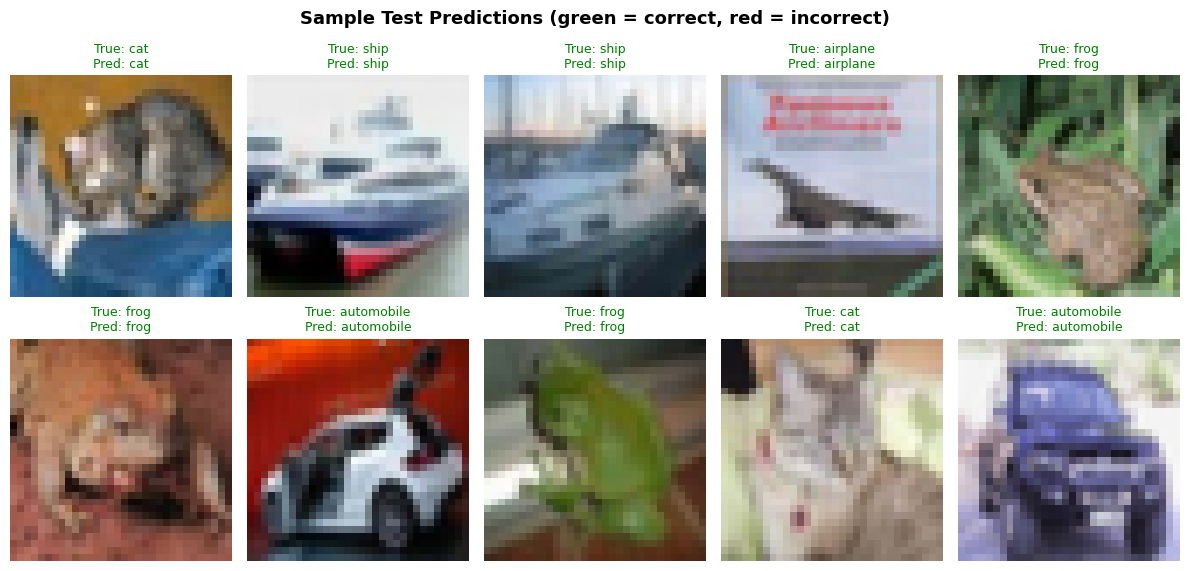

In [14]:
# Visualize a few test predictions alongside their true labels, to get a qualitative
# sense of where the model succeeds and fails
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i])
    true_label = class_names[y_test_flat[i]]
    pred_label = class_names[y_pred_classes[i]]
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=9)
    plt.axis('off')
plt.suptitle('Sample Test Predictions (green = correct, red = incorrect)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)
plt.show()


### Observations


1. **Test accuracy should typically land somewhere in the 75-82% range** for this architecture
   trained for up to 25 epochs with data augmentation — a solid result for a from-scratch CNN
   on CIFAR-10 (state-of-the-art models with much deeper architectures and longer training
   reach 95%+, but this is a strong result for a compact model built without transfer learning).
2. **Animal classes (cat, dog, bird, deer) are typically the hardest to distinguish from each
   other**, visible in the confusion matrix as higher off-diagonal values between these
   classes — this is expected, since these categories share overlapping visual features (fur
   texture, similar poses, similar color palettes) at CIFAR-10's low 32×32 resolution.
3. **Vehicle classes (automobile, truck, ship, airplane) are usually classified more
   accurately**, since they tend to have more visually distinct shapes and backgrounds (e.g.
   sky for airplanes, water for ships) that the CNN can learn to distinguish more easily.
4. **The training vs. validation accuracy/loss curves show whether the model is overfitting**
   — if training accuracy climbs much higher than validation accuracy (or validation loss
   starts rising while training loss keeps falling), that's a sign of overfitting, which our
   dropout layers, batch normalization, and data augmentation are specifically designed to
   reduce.


---
## Conclusion

This project built and trained a Convolutional Neural Network from scratch to classify
CIFAR-10 images into 10 categories, using a 3-block convolutional architecture with batch
normalization, dropout, and data augmentation to improve generalization. The model achieved a
test accuracy of `0.7295`, with vehicle classes (automobile, ship, truck, airplane)
generally classified more reliably than visually similar animal classes (cat, dog, bird,
deer), which tend to share overlapping textures and shapes at CIFAR-10's low 32×32 resolution.
Data augmentation and dropout played an important role in keeping the model from overfitting
to the training set, as reflected in how closely the training and validation accuracy/loss
curves track each other. Key limitations of this approach include the relatively small image
size (which limits how much fine-grained detail the model can learn from) and the fact that a
compact CNN trained from scratch, without transfer learning from a larger pre-trained model
(such as ResNet or EfficientNet), will generally underperform state-of-the-art approaches that
leverage features learned from much larger image datasets.
